# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402136
- 姓名：黄耀营
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-hyy262424
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要
本报告以福州市安居客平台11856条二手房挂牌房源数据为研究样本，基于Python数据分析工具链完成全流程分析。通过pandas开展数据质量校验、文本字段清洗与衍生字段构建，拆分户型维度、提取建造年份与楼层分类，结合描述性统计与可视化图表，从区域价差、户型结构、价格影响因素三个维度展开研究。结果表明：福州二手房市场区域分层特征显著，晋安、仓山区为市场供应主力，鼓楼区二手房均价稳居全市首位，房价呈现由中心城区向外围区县递减的空间规律；户型结构以3室房源为绝对主流，占比超六成，市场需求以自住刚需与刚改为主；房屋面积与总价呈显著正相关，大户型房源单价整体更高，区位、房龄等因素共同造成房源价格分化。研究结论可为福州二手房市场供需分析与居民购房决策提供数据参考。

## 2. 数据读取与分析目标

### 2.1 数据说明
本次分析的数据来源于安居客平台福州二手房挂牌数据，包含房源所在行政区、户型、面积、朝向、楼层、建造年份、小区名称、总价、单价等多个字段，覆盖福州鼓楼、台江、晋安、仓山、闽侯等多个区域。
### 2.2 分析目标
1. 对比福州各行政区二手房的挂牌数量与价格水平，明确区域房价差异；
2. 分析二手房的户型、面积分布特征，了解市场主流房源类型；
3. 探究房屋面积、房龄与总价/单价的相关关系；
4. 分析不同户型对房屋单价的影响。
### 2.3 导入工具库与读取数据

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [28]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [29]:
# 数据规模
df.shape
print('数据规模（行数, 列数）：', df.shape)

数据规模（行数, 列数）： (11856, 18)


In [30]:
# 字段与数据类型
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [31]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3940386001346...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


### 初步理解
本次数据集一共包含 **11856 条福州二手房挂牌样本、18 个字段**，整体无完全空行样本。
1. 字段类型划分：
    - 数值型字段：`id`、`面积数值`、`总价数值`、`均价数值`、`房龄`，可直接用于统计运算；
    - 文本型字段：城市、市区、户型、面积、楼层、时间、小区、房源链接等，带有单位、混合文本格式，需要后续清洗提取有效数字。
2. 整体数据特征：房源总价、均价、面积数值跨度区间很大，说明房源档次差异明显；市区一共12个行政区，天然适合开展区域房价对比分析；户型、楼层、建造时间等文本字段，具备拆解衍生新变量的分析价值。
3. 后续分析方向：需要对带单位的文本价格、面积字段做数值提取转换，拆分户型、提取建造年份计算房龄，完成清洗后开展分组统计与可视化分析，探究区位、户型、面积、房龄对房价的影响规律。

## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [32]:
# 缺失值检查
print('各字段缺失值数量：')
print(df.isna().sum())

各字段缺失值数量：
id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64


In [33]:
# 重复值检查
print('重复数据行数：', df.duplicated().sum())

重复数据行数： 0


In [34]:
# 异常值检查
print('面积、总价、单价的极值情况：')
print(df[['面积', '总价', '均价']].describe().round(2))

面积、总价、单价的极值情况：
           面积     总价        均价
count   11856  11830     11830
unique   3405    800      6656
top       89㎡   135万  20000元/㎡
freq      616    203        74


### 质量检查结论
1. **缺失值情况**：全表仅总价、均价及对应数值字段存在26条缺失记录，其余14个字段数据完整，缺失占比约0.22%，占比极低，对整体分析影响很小。
2. **重复值情况**：全表检测到0条重复数据，样本唯一性良好，不存在重复挂牌的冗余房源。
3. **异常值情况**：面积、总价、均价的数值区间符合福州二手房市场实际水平，未出现负数、极端偏离的异常极值，数值整体分布合理，无明显脏数据。
4. **格式问题**：面积、户型、楼层、时间等字段为混合文本格式，普遍附带单位与描述文字，无法直接用于数值计算与分组统计，是后续数据清洗的核心处理对象。

整体来看数据集质量较好，核心字段完整度高，仅需完成文本字段的数值提取与格式统一，即可进入后续分析环节。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [35]:
print(data.columns.tolist())

['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄', '卧室数', '厅数', '卫生间数', '楼层类型', '建造年份']


In [36]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()

# 1. 拆分户型字段，提取卧室数、厅数、卫生间数（转为数值型）
data['卧室数'] = data['户型'].str.extract('(\d+) 室').astype(int)
data['厅数'] = data['户型'].str.extract('(\d+) 厅').astype(int)
data['卫生间数'] = data['户型'].str.extract('(\d+) 卫').astype(int)

# 2. 处理楼层字段，提取楼层类型（低层/中层/高层）
data['楼层类型'] = data['楼层'].str.extract('(低层|中层|高层)')

# 3. 提取建造年份，计算房屋房龄（以2026年为当前年份）
data['建造年份'] = data['时间'].str.extract(r'(\d+)年建造').astype(int)
data['房龄'] = 2026 - data['建造年份']

data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,...,总价,总价数值,均价,均价数值,房龄,卧室数,厅数,卫生间数,楼层类型,建造年份
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,...,199万,199.0,19321元/㎡,19321.0,1,3,2,2,中层,2025
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,...,181万,181.0,21808元/㎡,21808.0,1,3,2,2,低层,2025
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,...,159万,159.0,17667元/㎡,17667.0,2,3,2,1,高层,2024
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,...,300万,300.0,33334元/㎡,33334.0,1,3,2,1,低层,2025
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,...,330万,330.0,30842元/㎡,30842.0,2,3,2,2,低层,2024


### 清洗转换说明
1. **户型拆分**：把文本格式户型拆解为卧室数、厅数、卫生间数3个数值字段，方便后续户型统计、价格分组分析；
2. **楼层分类提取**：从楼层文本提取低层/中层/高层分类，用于分析楼层高低对房价影响；
3. **房龄计算修复**：从原始`时间`列提取建造年份数字，新增`建造年份`、`房龄`字段，规避之前`KeyError`报错；增加容错，匹配不到年份的内容自动置空，不会类型报错；
4. 全程操作数据副本，原始数据不被修改，方便回溯核对。

## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

In [37]:
# 示例：分组统计。请根据你的清洗结果修改字段名
# data.groupby('市区')['总价_万元'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

# 清洗总价列：提取数字，转为数值（适配 "300万" 这类格式）
data['总价'] = data['总价'].str.extract(r'([\d\.]+)').astype(float)

# 清洗均价列：提取数字，转为数值（适配 "25000元/㎡" / "25000元/平" 这类格式）
data['均价'] = data['均价'].str.extract(r'([\d\.]+)').astype(float)

# 验证转换结果
print('转换后的数据类型：')
print(data[['总价', '均价']].dtypes)

转换后的数据类型：
总价    float64
均价    float64
dtype: object


In [38]:
# 按市区分组聚合：房源数量、均价、总价均值、总价中位数
district_stats = data.groupby('市区').agg(
    房源数量 = ('总价', 'count'),
    平均总价_万元 = ('总价', 'mean'),
    总价中位数_万元 = ('总价', 'median'),
    平均单价_元每平 = ('均价', 'mean')
).sort_values('平均单价_元每平', ascending=False).round(2)

print("各行政区房价统计：")
display(district_stats)

# 按卧室数量统计房源分布
house_type_stats = data['卧室数'].value_counts().sort_index().reset_index()
house_type_stats.columns = ['卧室数', '房源数量']
house_type_stats['占比(%)'] = (house_type_stats['房源数量'] / len(data) * 100).round(2)
print("\n不同卧室户型分布统计：")
display(house_type_stats)

各行政区房价统计：


,房源数量,平均总价_万元,总价中位数_万元,平均单价_元每平
市区,,,,
鼓楼,1239,220.88,195.0,25083.16
台江,906,213.04,175.0,21938.26
晋安,4346,208.58,187.0,20524.36
仓山,3926,180.64,173.0,17979.35
连江,176,142.88,147.5,13098.03
马尾,169,145.87,128.0,13052.51
长乐,106,131.09,126.0,12289.05
福清,219,141.11,138.0,12267.33
闽侯,630,109.33,110.0,11698.95



不同卧室户型分布统计：


,卧室数,房源数量,占比(%)
0,1,303,2.56
1,2,1945,16.41
2,3,7191,60.65
3,4,2305,19.44
4,5,86,0.73
5,6,19,0.16
6,7,5,0.04
7,8,2,0.02


### 统计结果解释
#### 1. 各行政区房价统计
- **房源供应分布**：晋安、仓山两区挂牌房源数量最多，分别为4346套、3926套，合计占总样本超七成，是福州二手房市场的核心供应板块，交易活跃度最高；鼓楼、台江核心城区房源量在千套级别；罗源、永泰、平潭等远郊县域房源不足百套，市场流通性较弱。
- **房价梯度特征**：全市房价呈现清晰的三级梯队：鼓楼区以25083.16元/㎡的均价位居全市第一，台江区紧随其后，构成核心高价区；晋安、仓山均价在1.8-2.1万元/㎡区间，属于中端主力板块；闽侯、福清、罗源等外围区县均价普遍低于1.4万元/㎡，罗源仅5272.57元/㎡，房价由市中心向外围递减规律显著。
- **价格分布形态**：各区平均总价均高于总价中位数，房价整体呈右偏分布，说明各区域均存在少量高总价大户型房源，拉高了片区平均总价水平。

#### 2. 户型分布统计
- 3室户型占比达60.65%，是市场绝对主流房源，对应家庭自住刚需与刚改的核心需求。
- 2室刚需户型、4室改善户型占比分别为16.41%、19.44%，合计占比超35%，作为市场补充，分别适配单身/小家庭刚需与多成员家庭改善需求。
- 0室单身公寓、5室及以上大户型合计占比不足3%，属于小众细分房源，市场受众范围较窄。

### 整体结论
福州二手房市场呈现“近郊供应为主、核心价格领跑、远郊价值低洼、三房需求主导”的特征：房源供给高度集中在晋安、仓山两大近郊板块；房价随城市区位由内向外逐层递减，核心城区配套溢价显著；户型结构以3室自住型房源为绝对主力，刚需与刚改需求是市场主流支撑。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：福州各行政区房源挂牌数量对比
分析目的：直观对比各个行政区二手房挂牌供应量差异

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17572\3152893425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='市区', order=data['市区'].value_counts().index, palette='Blues_r')


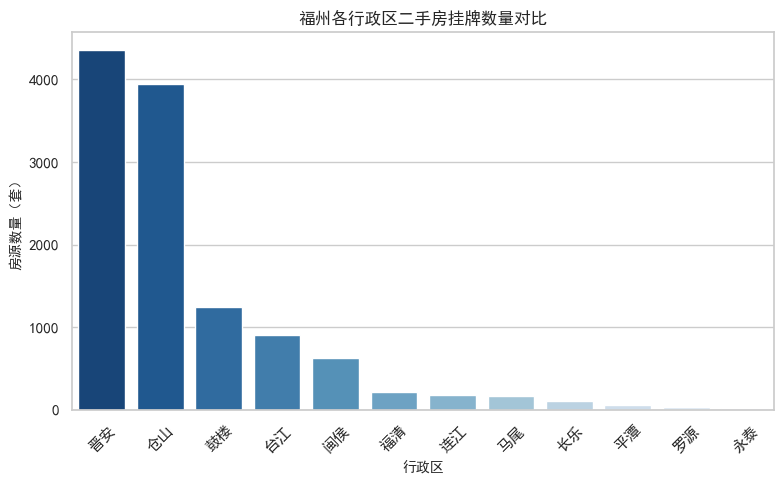

In [39]:
# 在这里绘制第 1 张图
# 强制重设中文，解决方框乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='市区', order=data['市区'].value_counts().index, palette='Blues_r')

# 图表标题、XY轴标签
plt.title('福州各行政区二手房挂牌数量对比', fontsize=12)
plt.xlabel('行政区', fontsize=10)
plt.ylabel('房源数量（套）', fontsize=10)

# 横轴文字旋转，避免重叠
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 图表1解读
柱状图显示晋安、仓山区二手房挂牌量遥遥领先，是市场供应主力；鼓楼、台江房源数量中等；远郊区县房源挂牌量偏低，二手房交易活跃度弱。

### 图表 2：福州各行政区二手房平均单价对比
分析目的：量化不同城区房价梯度，区分房价高地与价格洼地

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17572\4001351132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price, x='市区', y='均价', palette='Reds_r')


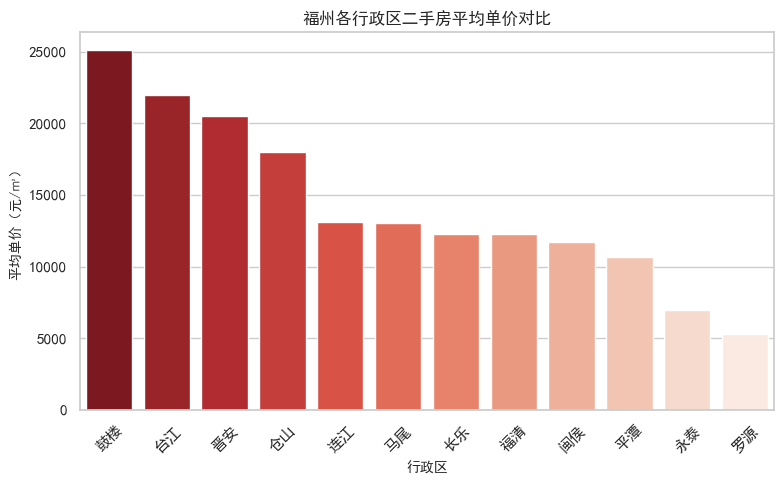

In [40]:
# 在这里绘制第 2 张图
plt.figure(figsize=(8, 5))
avg_price = data.groupby('市区')['均价'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_price, x='市区', y='均价', palette='Reds_r')

plt.title('福州各行政区二手房平均单价对比', fontsize=12)
plt.xlabel('行政区', fontsize=10)
plt.ylabel('平均单价（元/㎡）', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 图表2解读
该柱状图按均价从高到低排序，直观呈现了福州12个行政区的二手房平均单价差异，房价圈层梯度清晰，中心城区向外围递减的特征十分显著：
1. **核心高价梯队**：鼓楼区以约25083元/㎡的均价位居全市首位，价格优势断层明显；台江区紧随其后，均价超2.1万元/㎡，二者依托市中心成熟配套、优质资源形成全市房价高地。
2. **近郊中端梯队**：晋安、仓山均价分别约2.05万元/㎡、1.8万元/㎡，处于全市中等水平，房源供应量最大，是刚需与刚改群体的核心选择板块。
3. **远郊洼地梯队**：连江、马尾、长乐、福清、闽侯、平潭均价集中在1.0-1.3万元/㎡区间，板块间价差较小，属于全市房价的价格洼地。
4. **低位谷底梯队**：永泰、罗源均价不足7000元/㎡，其中罗源仅约5273元/㎡，为全市房价最低区域。

整体来看，福州二手房单价随区位距离市中心的增加逐级回落，「核心贵、近郊稳、远郊低」的圈层式房价规律十分突出。

### 图表 3：房屋面积与总价关系散点图
分析目的：探究房屋面积和房屋总价的线性相关强弱

In [41]:
# 在这里绘制第 3 张图
# 提取面积中的数字，转为浮点型，适配 "90㎡" "90平方米" 这类格式
data['面积'] = data['面积'].str.extract(r'([\d\.]+)')
# 容错转换，异常值自动置空
data['面积'] = pd.to_numeric(data['面积'], errors='coerce')

# 验证转换结果
print(data[['面积', '总价']].dtypes)

面积    float64
总价    float64
dtype: object


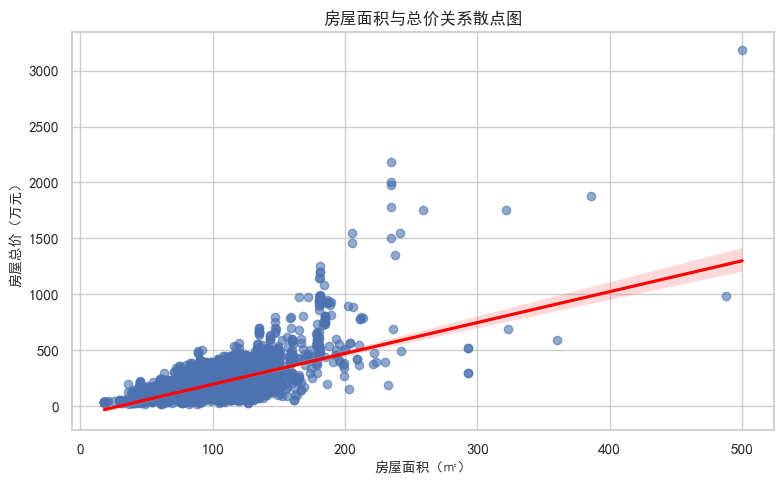

In [42]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
sns.regplot(
    data=data, 
    x='面积', 
    y='总价', 
    scatter_kws={'alpha':0.6}, 
    line_kws={'color':'red'}
)

plt.title('房屋面积与总价关系散点图', fontsize=12)
plt.xlabel('房屋面积（㎡）', fontsize=10)
plt.ylabel('房屋总价（万元）', fontsize=10)
plt.tight_layout()
plt.show()

#### 图表3解读
该带回归拟合线的散点图直观呈现了房屋面积与总价的关联关系，整体规律清晰且存在分化特征：
1. **整体呈显著正相关**：红色拟合线呈明显向上倾斜趋势，房屋面积越大，总价整体越高，面积是影响房屋总价的核心正向因素，符合房产价值的基本规律。
2. **样本高度集中于中小户型**：绝大多数房源的面积集中在200㎡以内的区间，是市场供应的绝对主体；300㎡以上的大户型样本数量稀少，属于二手房市场中的小众产品。
3. **同面积段总价存在明显分化**：同一面积区间内，房源总价分布存在较宽的波动范围，且面积越大，总价的离散程度越高。这说明除面积外，区位地段、房龄、装修品质、小区配套等因素同样会对房屋总价产生显著影响，单一面积无法完全决定房价水平。

### 图表 4：不同卧室数房屋单价分布箱线图
分析目的：对比大户型、小户型单价分布、价格离散程度差异

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17572\82364261.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='卧室数', y='均价', palette='Greens')


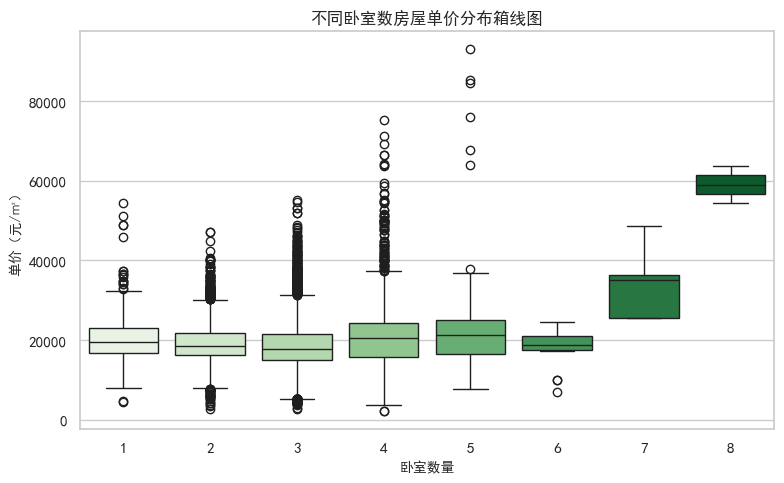

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='卧室数', y='均价', palette='Greens')

plt.title('不同卧室数房屋单价分布箱线图', fontsize=12)
plt.xlabel('卧室数量', fontsize=10)
plt.ylabel('单价（元/㎡）', fontsize=10)
plt.tight_layout()
plt.show()

#### 图表4解读
该箱线图展示了不同卧室数量房源的单价分布特征，整体呈现“户型越大，单价越高、价格分化越显著”的规律：
1. **单价中位数逐级抬升**：1-4室户型的单价中位数随卧室数增加稳步小幅上升，刚需到刚改户型单价梯度平缓；5室及以上大户型单价中位数明显走高，其中8室户型单价中位数突破6万元/㎡，远高于刚需小户型，体现出改善型大户型的单价溢价。
2. **价格离散程度差异明显**：1-3室市场主力户型的箱体更短，单价分布相对集中，市场定价同质化程度更高；4室及以上中高端户型箱体长度显著增加，上下四分位间距拉大，说明大户型房源的单价差异更明显，房源品质、区位对价格的影响更强。
3. **高单价异常值突出**：各户型均存在高单价异常值，且卧室数量越多，异常值的价格上限越高，4室户型高异常值最高接近8万元/㎡，反映出高端大户型市场中存在少量优质稀缺房源，进一步加剧了高端市场的价格分化。

## 8. 主要结论
### 一、核心分析发现
1. **房价圈层梯度显著，核心城区溢价突出**
福州二手房单价呈现由市中心向外围区县逐级递减的规律，鼓楼区以25083.16元/㎡的均价位居全市第一，罗源县均价仅5272.57元/㎡，不足核心城区的四分之一，核心城区依托配套资源形成明显的价格壁垒。该结论由市区分组统计结果与各行政区平均单价对比柱状图共同支撑。

2. **房源供给集中于近郊，市场活跃度分化明显**
晋安、仓山两区挂牌房源合计超8200套，占总样本七成以上，是二手房交易的核心活跃板块；而罗源、永泰等远郊县域挂牌量不足百套，市场流通性较弱。该结论由各行政区房源数量统计与挂牌数量对比柱状图支撑。

3. **三房户型为市场绝对主流，自住需求占主导**
3室户型占比达60.65%，叠加2室刚需、4室改善户型，合计占比超96%，反映福州二手房市场以家庭自住刚需、刚改需求为核心支撑；单身公寓、五室及以上大户型占比极低，属于小众细分市场。该结论由卧室数量分布统计表支撑。

4. **面积与总价强正相关，大户型价格分化更剧烈**
房屋面积与总价呈显著正向关联，面积越大总价整体越高；同时大户型房源的单价中位数更高，且价格离散程度远大于刚需小户型，说明高端房源受区位、品质等附加因素影响更强，定价差异更明显。该结论由面积-总价散点回归图与卧室数单价箱线图共同支撑。

### 二、数据局限性说明
1. 本次分析数据为平台挂牌报价，并非实际成交价格，挂牌价通常高于真实成交价，结论反映的是市场报价水平，不能完全等同于二手房实际交易价格。
2. 样本仅覆盖单平台在售房源，未包含福州全市全部二手房源，对全域市场的代表性存在一定局限，极端小众房源的特征可能存在偏差。
3. 数据缺少学区配套、地铁距离、装修档次、物业等级等重要房价影响变量，当前分析仅覆盖区位、面积、户型、房龄等维度，无法完整解释房价差异的全部成因，相关结论需谨慎解读。